# 02 — Synthetic Data Generation & Enrichment

Generates synthetic offer-interaction events and a golden evaluation set from the real bank marketing dataset.  
All outputs use **synthetic IDs** — no PII, LGPD-compliant.

**Outputs:**
- `data/synthetic_enrichment/interaction_events.parquet` — 50 000 synthetic bandit events
- `data/golden_set/evaluation_cases.parquet` — 500 labelled evaluation records

In [1]:
from pathlib import Path
import sys

ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams["figure.dpi"] = 110
plt.rcParams["figure.figsize"] = (10, 4)

print(f"Working from: {ROOT}")

DATA_PATH = ROOT / "data" / "kaggle" / "bank_marketing_dataset" / "bank-additional-full.csv"
print(f"Dataset path: {DATA_PATH}")
print(f"Exists: {DATA_PATH.exists()}")

df = pd.read_csv(DATA_PATH, sep=";")

Working from: /Volumes/zeus/project/project_persona/git-portfolio/postech-fiap-ml-tech-challege-5-datathon
Dataset path: /Volumes/zeus/project/project_persona/git-portfolio/postech-fiap-ml-tech-challege-5-datathon/data/kaggle/bank_marketing_dataset/bank-additional-full.csv
Exists: True


## 1. Generate Synthetic Data

In [3]:
from src.data.loader import clean, save_processed, PROCESSED_PATH
from src.data.synthetic import save_all

# Ensure processed data exists (needed by save_all)
if not PROCESSED_PATH.exists():
    print("Processed data not found — running preprocessing first...")
    df_clean = clean(df)
    save_processed(df_clean)
    print(f"Saved processed data to {PROCESSED_PATH}")

save_all()
print("Synthetic data written to disk.")

Saved offers_catalog.json
Saved interaction_events.parquet (50,000 rows)
Saved evaluation_cases.parquet (500 rows)
Golden set reward rate: 0.206
Synthetic data written to disk.


## 2. Inspect Interaction Events

In [6]:
interactions = pd.read_parquet(ROOT /"data" / "synthetic_enrichment" / "interaction_events.parquet")
print(f"Shape: {interactions.shape}")
print(f"Columns: {list(interactions.columns)}")
interactions.head(5)

Shape: (50000, 10)
Columns: ['event_id', 'session_id', 'arm_selected', 'client_segment', 'reward', 'age', 'job', 'education', 'housing', 'euribor3m']


,event_id,session_id,arm_selected,client_segment,reward,age,job,education,housing,euribor3m
0,evt_000000,sess_000000,savings_account,age_young,0,29,admin.,university.degree,yes,4.960
1,evt_000001,sess_000001,personal_loan,indebted,0,40,management,university.degree,yes,4.856
2,evt_000002,sess_000002,personal_loan,indebted,0,35,admin.,high.school,yes,0.754
3,evt_000003,sess_000003,term_deposit_12m,age_young,0,37,management,university.degree,no,4.961
4,evt_000004,sess_000004,term_deposit_12m,age_senior,0,58,retired,professional.course,no,4.857


In [7]:
print("Dtypes:")
print(interactions.dtypes)
print(f"\nMissing: {interactions.isnull().sum().sum()}")
print(f"\nArm distribution:")
print(interactions["arm_selected"].value_counts(normalize=True).round(3))

Dtypes:
event_id           object
session_id         object
arm_selected       object
client_segment     object
reward              int64
age                 int64
job                object
education          object
housing            object
euribor3m         float64
dtype: object

Missing: 0

Arm distribution:
arm_selected
personal_loan       0.202
savings_account     0.200
term_deposit_12m    0.200
term_deposit_6m     0.199
premium_savings     0.198
Name: proportion, dtype: float64


## 3. Reward Distribution by Arm

In [8]:
reward_by_arm = interactions.groupby("arm_selected")["reward"].agg(["mean", "sum", "count"])
reward_by_arm.columns = ["conversion_rate", "total_reward", "n_events"]
reward_by_arm = reward_by_arm.sort_values("conversion_rate", ascending=False)
print(reward_by_arm.round(4))

                  conversion_rate  total_reward  n_events
arm_selected                                             
term_deposit_12m           0.1537          1535      9986
term_deposit_6m            0.1526          1520      9961
premium_savings            0.1495          1482      9913
personal_loan              0.1421          1437     10115
savings_account            0.0907           909     10025


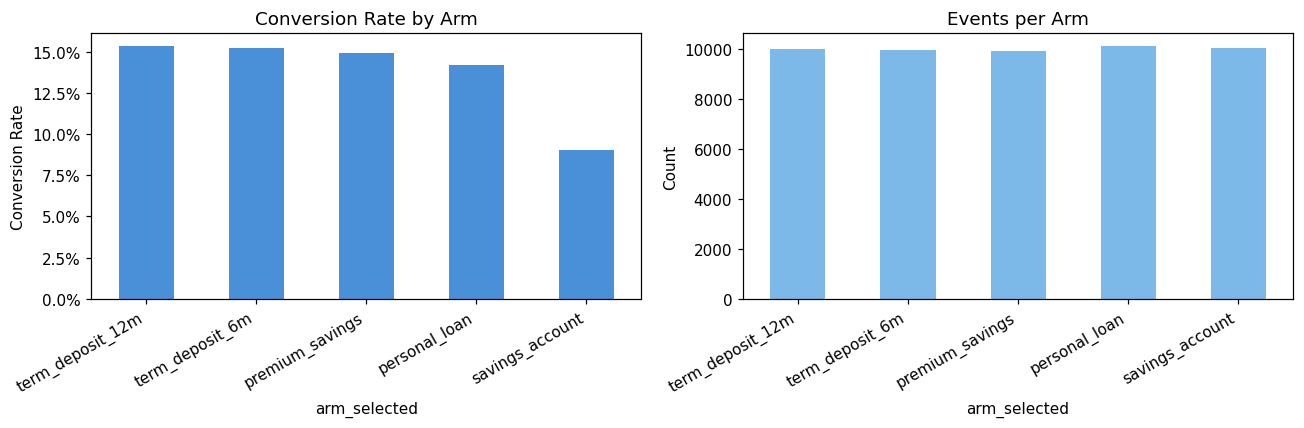

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

reward_by_arm["conversion_rate"].plot(kind="bar", ax=axes[0], color="#4A90D9")
axes[0].set_title("Conversion Rate by Arm")
axes[0].set_ylabel("Conversion Rate")
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha="right")

reward_by_arm["n_events"].plot(kind="bar", ax=axes[1], color="#7CB9E8")
axes[1].set_title("Events per Arm")
axes[1].set_ylabel("Count")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha="right")

plt.tight_layout()
plt.show()

## 4. Segment × Arm Heatmap

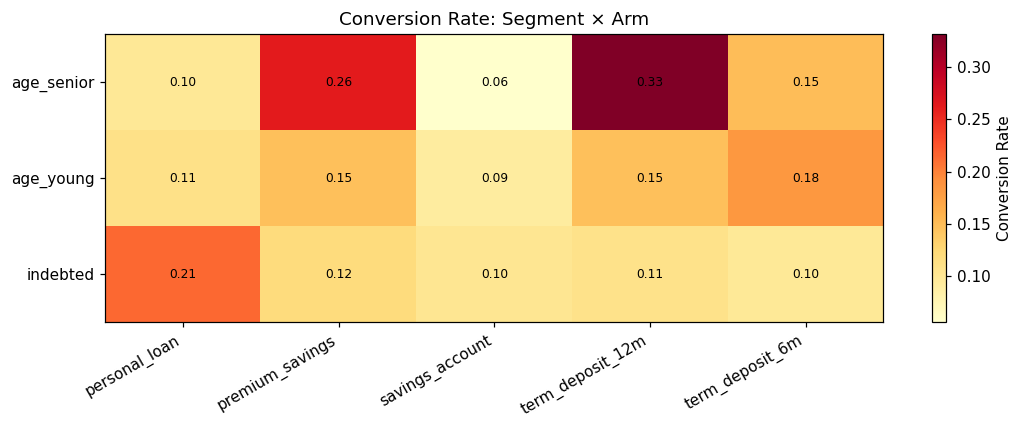

In [10]:
if "client_segment" in interactions.columns:
    pivot = interactions.groupby(["client_segment", "arm_selected"])["reward"].mean().unstack()
    fig, ax = plt.subplots(figsize=(10, 4))
    im = ax.imshow(pivot.values, cmap="YlOrRd", aspect="auto")
    plt.colorbar(im, ax=ax, label="Conversion Rate")
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_yticks(range(len(pivot.index)))
    ax.set_xticklabels(pivot.columns, rotation=30, ha="right")
    ax.set_yticklabels(pivot.index)
    ax.set_title("Conversion Rate: Segment × Arm")
    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            ax.text(j, i, f"{pivot.values[i,j]:.2f}", ha="center", va="center", fontsize=8)
    plt.tight_layout()
    plt.show()
else:
    print("No 'client_segment' column — skipping heatmap.")

## 5. Inspect Golden Set

In [16]:
golden = pd.read_parquet(ROOT / "data" / "golden_set" / "evaluation_cases.parquet")
print(f"Shape: {golden.shape}")
print(f"Columns: {list(golden.columns)}")
golden.head(5)

Shape: (500, 9)
Columns: ['case_id', 'arm_historical', 'reward', 'client_segment', 'age', 'job', 'education', 'housing', 'euribor3m']


,case_id,arm_historical,reward,client_segment,age,job,education,housing,euribor3m
0,case_0000,term_deposit_6m,0,age_young,32,technician,university.degree,no,4.966
1,case_0001,personal_loan,1,indebted,48,admin.,basic.9y,yes,4.859
2,case_0002,personal_loan,1,indebted,41,blue-collar,basic.4y,no,1.410
3,case_0003,personal_loan,0,indebted,38,blue-collar,basic.9y,yes,1.344
4,case_0004,personal_loan,0,indebted,46,technician,professional.course,yes,4.866


In [17]:
print("Golden set arm distribution:")
print(golden["arm_historical"].value_counts(normalize=True).round(3))
print(f"\nOverall golden set conversion: {golden['reward'].mean():.3f}")

Golden set arm distribution:
arm_historical
term_deposit_6m     0.536
personal_loan       0.356
term_deposit_12m    0.108
Name: proportion, dtype: float64

Overall golden set conversion: 0.206


## 6. LGPD Compliance Verification

In [18]:
PII_PATTERNS = ["cpf", "nome", "name", "telefone", "phone", "email", "rg", "cnpj"]

for df_name, frame in [("interactions", interactions), ("golden_set", golden)]:
    violations = [c for c in frame.columns if any(p in c.lower() for p in PII_PATTERNS)]
    status = "PASS" if not violations else f"FAIL: {violations}"
    print(f"{df_name}: {status}")

print("\nNo PII columns detected — LGPD-compliant.")

interactions: PASS
golden_set: PASS

No PII columns detected — LGPD-compliant.
